In [1]:
import pandas as pd
import seaborn as sns

In [2]:
rolls = pd.read_excel('dieRollsStatic.xlsx').drop('Fingers Crossed', axis=1).reset_index()

In [3]:
rollsStacked = pd.melt(rolls, id_vars='index', var_name='Die Type', value_name='Roll Value')
#pd.melt(rolls, var_name='Die Type', value_vars=['d4', 'd6', 'd8', 'd10', 'd12', 'd20', 'd100'], value_name='Roll Value')

In [4]:
rolls.head()

,index,d4,d6,d8,d10,d12,d20,d100
0,0,1,1,6,2,11,2,67
1,1,4,2,5,8,6,8,21
2,2,1,4,6,7,8,20,67
3,3,1,2,1,4,3,16,59
4,4,3,2,7,7,7,8,56


In [5]:
rollsStacked.head()

,index,Die Type,Roll Value
0,0,d4,1
1,1,d4,4
2,2,d4,1
3,3,d4,1
4,4,d4,3


<AxesSubplot:xlabel='Die Type', ylabel='Roll Value'>

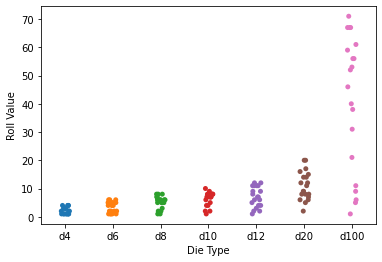

In [6]:
sns.stripplot(data=rollsStacked, x='Die Type', y='Roll Value')

In [9]:
rollsStacked['Normalized Value'] = rollsStacked.apply(normalize, axis=1)

In [8]:
def normalize(row):
    maxRoll = {'d4': 4, 'd6': 6,
               'd8': 8, 'd10': 10,
               'd12': 12, 'd20': 20,
               'd100': 100}
    
    return row['Roll Value']/maxRoll[row['Die Type']]

In [10]:
normalize(rollsStacked.iloc[0, :])

0.25

In [11]:
import matplotlib.pyplot as plt

<AxesSubplot:xlabel='Die Type', ylabel='Normalized Value'>

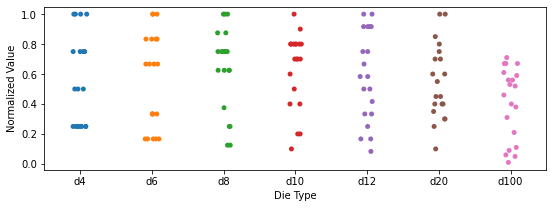

In [12]:
fig, ax = plt.subplots(figsize=(9, 3))
sns.stripplot(data=rollsStacked, x='Die Type', y='Normalized Value', ax=ax,
         )

In [13]:
rolls = pd.read_excel('dieRollsStatic.xlsx').reset_index()
rollsStacked = pd.melt(rolls, id_vars=['index', 'Fingers Crossed'], var_name='Die Type', value_name='Roll Value')
rollsStacked['Normalized Value'] = rollsStacked.apply(normalize, axis=1)

(-0.1, 1.4)

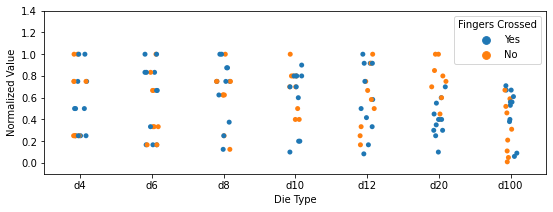

In [14]:
fig, ax = plt.subplots(figsize=(9, 3))
sns.stripplot(data=rollsStacked, x='Die Type', y='Normalized Value', ax=ax,
              hue='Fingers Crossed')

ax.set_ylim([-0.1, 1.4])

In [19]:
rollsStacked.pivot(index=['index', 'Fingers Crossed'], columns='Die Type', values='Roll Value').reset_index()

Die Type,index,Fingers Crossed,d10,d100,d12,d20,d4,d6,d8
0,0,Yes,2,67,11,2,1,1,6
1,1,No,8,21,6,8,4,2,5
2,2,No,7,67,8,20,1,4,6
3,3,No,4,59,3,16,1,2,1
4,4,Yes,7,56,7,8,3,2,7
5,5,Yes,8,9,1,12,2,5,3
6,6,No,8,46,2,12,1,4,5
7,7,Yes,8,53,6,11,1,1,7
8,8,No,7,5,9,9,3,2,8
9,9,No,10,1,7,20,3,1,6


In [21]:
rolls.describe()

,index,d4,d6,d8,d10,d12,d20,d100
count,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,9.50000,2.250000,3.350000,5.150000,6.350000,7.050000,10.950000,40.850000
std,5.91608,1.208522,1.899446,2.230766,2.518876,3.619756,5.010253,24.002796
min,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000
25%,4.75000,1.000000,1.750000,4.500000,4.750000,4.000000,7.750000,18.500000
50%,9.50000,2.000000,4.000000,6.000000,7.000000,7.000000,10.000000,49.000000
75%,14.25000,3.000000,5.000000,6.250000,8.000000,11.000000,14.250000,59.500000
max,19.00000,4.000000,6.000000,8.000000,10.000000,12.000000,20.000000,71.000000


In [32]:
rolls.groupby(by='Fingers Crossed').agg(perc25)

,index,d4,d6,d8,d10,d12,d20,d100
Fingers Crossed,,,,,,,,
No,3,1,2.0,5,5,4.0,12,11
Yes,6,1,1.5,4,4,4.5,6,39


In [28]:
import numpy as np

In [31]:
def perc25(data):
    return np.percentile(data, 25)